<a href="https://colab.research.google.com/github/PriyankaDevaprasad/Projects/blob/main/Project_2_Global_Literacy_Education.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DATA COLLECTION**

In [1]:
import pandas as pd

df_adult = pd.read_csv("https://ourworldindata.org/grapher/literacy-rate-adults.csv?v=1&csvType=full&useColumnShortNames=true",storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

df_adult.head()

,entity,code,year,adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99
0,Afghanistan,AFG,1979,18.00000
1,Afghanistan,AFG,2011,31.00000
2,Afghanistan,AFG,2015,33.75384
3,Afghanistan,AFG,2021,37.00000
4,Albania,ALB,2001,99.00000


In [2]:
df_youth = pd.read_csv("https://ourworldindata.org/grapher/literacy-rate-of-young-men-and-women.csv?v=1&csvType=full&useColumnShortNames=true",storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

df_youth.head()

,entity,code,year,youth_literacy_rate__population_15_24_years__male__pct__lr_ag15t24_m,youth_literacy_rate__population_15_24_years__female__pct__lr_ag15t24_f,owid_region
0,Afghanistan,AFG,1979,46.00000,11.00000,Asia
1,Afghanistan,AFG,2011,62.00000,32.00000,Asia
2,Afghanistan,AFG,2015,57.73505,25.48416,Asia
3,Afghanistan,AFG,2021,71.00000,42.00000,Asia
4,Afghanistan,AFG,2022,83.40000,44.17171,Asia


In [3]:
df_illeterate = pd.read_csv("https://ourworldindata.org/grapher/literate-and-illiterate-world-population.csv?v=1&csvType=full&useColumnShortNames=true",storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

df_illeterate.head()

,entity,code,year,illiteracy_rate,literacy_rate
0,Afghanistan,AFG,1950,97.000000,3.00000
1,Afghanistan,AFG,1979,82.000000,18.00000
2,Afghanistan,AFG,2011,69.000000,31.00000
3,Afghanistan,AFG,2015,66.246155,33.75384
4,Afghanistan,AFG,2021,63.000000,37.00000


In [4]:
df_gdp = pd.read_csv("https://ourworldindata.org/grapher/gdp-per-capita-worldbank.csv?v=1&csvType=full&useColumnShortNames=true",storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

df_gdp.head()

,entity,code,year,ny_gdp_pcap_pp_kd,owid_region
0,Afghanistan,AFG,2000,1617.8264,Asia
1,Afghanistan,AFG,2001,1454.1108,Asia
2,Afghanistan,AFG,2002,1774.3087,Asia
3,Afghanistan,AFG,2003,1815.9282,Asia
4,Afghanistan,AFG,2004,1776.9182,Asia


In [5]:
df_schooling = pd.read_csv("https://ourworldindata.org/grapher/literacy-rates-vs-average-years-of-schooling.csv?v=1&csvType=full&useColumnShortNames=true",storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

df_schooling.head()

,entity,code,year,literacy_rate,mf_youth_and_adults__15_64_years__average_years_of_education,population_historical,owid_region
0,Afghanistan,AFG,1870,NaN,0.01,4101170.0,Asia
1,Afghanistan,AFG,1875,NaN,0.01,4193635.0,Asia
2,Afghanistan,AFG,1880,NaN,0.01,4288021.0,Asia
3,Afghanistan,AFG,1885,NaN,0.01,4384343.0,Asia
4,Afghanistan,AFG,1890,NaN,0.01,4482635.0,Asia


**Understanding the data**

In [6]:
def data_analysis(df, name):
    print("------------------------------------------")
    print(f"*****************{name}*****************")
    print("---Shape:", df.shape)
    print("\n-----",df.info())
    print("\n-----Missing Values:\n", df.isnull().sum())

data_analysis(df_adult, "Adult Literacy")
data_analysis(df_youth, "Youth Literacy")
data_analysis(df_illeterate, "Illiteracy Population")
data_analysis(df_gdp, "GDP per Capita")
data_analysis(df_schooling, "Schooling Years")

------------------------------------------
*****************Adult Literacy*****************
---Shape: (1725, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1725 entries, 0 to 1724
Data columns (total 4 columns):
 #   Column                                                                     Non-Null Count  Dtype  
---  ------                                                                     --------------  -----  
 0   entity                                                                     1725 non-null   object 
 1   code                                                                       996 non-null    object 
 2   year                                                                       1725 non-null   int64  
 3   adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99  1725 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 54.0+ KB

----- None

-----Missing Values:
 entity                                                      

# **Merging the data**

Literacy rates

In [7]:
df_literacy=pd.merge(df_adult,df_youth,on=['entity','code','year'],how='outer')
df_literacy

,entity,code,year,adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99,youth_literacy_rate__population_15_24_years__male__pct__lr_ag15t24_m,youth_literacy_rate__population_15_24_years__female__pct__lr_ag15t24_f,owid_region
0,Afghanistan,AFG,1979,18.00000,46.00000,11.00000,Asia
1,Afghanistan,AFG,2011,31.00000,62.00000,32.00000,Asia
2,Afghanistan,AFG,2015,33.75384,57.73505,25.48416,Asia
3,Afghanistan,AFG,2021,37.00000,71.00000,42.00000,Asia
4,Afghanistan,AFG,2022,NaN,83.40000,44.17171,Asia
...,...,...,...,...,...,...,...
2014,Zimbabwe,ZWE,1982,78.00000,94.00000,85.00000,Africa
2015,Zimbabwe,ZWE,1992,84.00000,97.00000,94.00000,Africa
2016,Zimbabwe,ZWE,2009,NaN,NaN,95.65000,Africa
2017,Zimbabwe,ZWE,2014,NaN,NaN,96.31000,Africa


In [9]:
df_literacy=df_literacy.rename(columns={"entity":"country","adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99":"adult_literacy_rate","youth_literacy_rate__population_15_24_years__male__pct__lr_ag15t24_m":"youth_literacy_rate_male","youth_literacy_rate__population_15_24_years__female__pct__lr_ag15t24_f":"youth_literacy_rate_female","owid_region":"region"})
df_literacy

,country,code,year,adult_literacy_rate,youth_literacy_rate_male,youth_literacy_rate_female,region
0,Afghanistan,AFG,1979,18.00000,46.00000,11.00000,Asia
1,Afghanistan,AFG,2011,31.00000,62.00000,32.00000,Asia
2,Afghanistan,AFG,2015,33.75384,57.73505,25.48416,Asia
3,Afghanistan,AFG,2021,37.00000,71.00000,42.00000,Asia
4,Afghanistan,AFG,2022,NaN,83.40000,44.17171,Asia
...,...,...,...,...,...,...,...
2014,Zimbabwe,ZWE,1982,78.00000,94.00000,85.00000,Africa
2015,Zimbabwe,ZWE,1992,84.00000,97.00000,94.00000,Africa
2016,Zimbabwe,ZWE,2009,NaN,NaN,95.65000,Africa
2017,Zimbabwe,ZWE,2014,NaN,NaN,96.31000,Africa


Filtering the data from 1990 to 2026

In [10]:
df_literacy = df_literacy[(df_literacy['year'] >= 1990) & (df_literacy['year'] <= 2026)]
df_literacy.head()

,country,code,year,adult_literacy_rate,youth_literacy_rate_male,youth_literacy_rate_female,region
1,Afghanistan,AFG,2011,31.00000,62.00000,32.00000,Asia
2,Afghanistan,AFG,2015,33.75384,57.73505,25.48416,Asia
3,Afghanistan,AFG,2021,37.00000,71.00000,42.00000,Asia
4,Afghanistan,AFG,2022,NaN,83.40000,44.17171,Asia
5,Albania,ALB,2001,99.00000,99.00000,99.00000,Europe


In [11]:
df_literacy['country'].value_counts()

,count
country,
East Asia and Pacific (WB),34
Eastern and South-Eastern Asia (SDG),34
Europe and Central Asia (WB),34
Central and Southern Asia (SDG),34
South Asia (WB),34
...,...
Saint Lucia,1
San Marino,1
Saint Helena,1


GDP and Schooling data

In [8]:
df_gdp_schooling=pd.merge(df_gdp,df_schooling,on=['entity','code','year','owid_region'],how='outer')
df_gdp_schooling

,entity,code,year,ny_gdp_pcap_pp_kd,owid_region,literacy_rate,mf_youth_and_adults__15_64_years__average_years_of_education,population_historical
0,Afghanistan,AFG,1870,NaN,Asia,NaN,0.01,4101170.0
1,Afghanistan,AFG,1875,NaN,Asia,NaN,0.01,4193635.0
2,Afghanistan,AFG,1880,NaN,Asia,NaN,0.01,4288021.0
3,Afghanistan,AFG,1885,NaN,Asia,NaN,0.01,4384343.0
4,Afghanistan,AFG,1890,NaN,Asia,NaN,0.01,4482635.0
...,...,...,...,...,...,...,...,...
11006,Zimbabwe,ZWE,2020,4527.7197,Africa,NaN,8.32,15526887.0
11007,Zimbabwe,ZWE,2021,4827.0890,Africa,NaN,NaN,NaN
11008,Zimbabwe,ZWE,2022,5036.7610,Africa,NaN,NaN,NaN
11009,Zimbabwe,ZWE,2023,5218.0225,Africa,NaN,NaN,NaN


In [14]:
df_gdp_schooling=df_gdp_schooling.rename(columns={"entity":"country","ny_gdp_pcap_pp_kd":"gdp","owid_region":"region","mf_youth_and_adults__15_64_years__average_years_of_education":"average_years_of_schooling","population_historical":"population"})
df_gdp_schooling

,country,code,year,gdp,region,literacy_rate,average_years_of_schooling,population
0,Afghanistan,AFG,1870,NaN,Asia,NaN,0.01,4101170.0
1,Afghanistan,AFG,1875,NaN,Asia,NaN,0.01,4193635.0
2,Afghanistan,AFG,1880,NaN,Asia,NaN,0.01,4288021.0
3,Afghanistan,AFG,1885,NaN,Asia,NaN,0.01,4384343.0
4,Afghanistan,AFG,1890,NaN,Asia,NaN,0.01,4482635.0
...,...,...,...,...,...,...,...,...
11006,Zimbabwe,ZWE,2020,4527.7197,Africa,NaN,8.32,15526887.0
11007,Zimbabwe,ZWE,2021,4827.0890,Africa,NaN,NaN,NaN
11008,Zimbabwe,ZWE,2022,5036.7610,Africa,NaN,NaN,NaN
11009,Zimbabwe,ZWE,2023,5218.0225,Africa,NaN,NaN,NaN


Dropping data with so many missing vaues


In [15]:
df_gdp_schooling=df_gdp_schooling.drop(columns=['literacy_rate'])
df_gdp_schooling

,country,code,year,gdp,region,average_years_of_schooling,population
0,Afghanistan,AFG,1870,NaN,Asia,0.01,4101170.0
1,Afghanistan,AFG,1875,NaN,Asia,0.01,4193635.0
2,Afghanistan,AFG,1880,NaN,Asia,0.01,4288021.0
3,Afghanistan,AFG,1885,NaN,Asia,0.01,4384343.0
4,Afghanistan,AFG,1890,NaN,Asia,0.01,4482635.0
...,...,...,...,...,...,...,...
11006,Zimbabwe,ZWE,2020,4527.7197,Africa,8.32,15526887.0
11007,Zimbabwe,ZWE,2021,4827.0890,Africa,NaN,NaN
11008,Zimbabwe,ZWE,2022,5036.7610,Africa,NaN,NaN
11009,Zimbabwe,ZWE,2023,5218.0225,Africa,NaN,NaN


Filtering data from 1990 to 2026

In [16]:
df_gdp_schooling=df_gdp_schooling[(df_gdp_schooling['year']>=1910) & (df_gdp_schooling['year']<=2026)]
df_gdp_schooling

,country,code,year,gdp,region,average_years_of_schooling,population
8,Afghanistan,AFG,1910,NaN,Asia,0.01,5504191.0
9,Afghanistan,AFG,1915,NaN,Asia,0.02,7654918.0
10,Afghanistan,AFG,1920,NaN,Asia,0.03,10188845.0
11,Afghanistan,AFG,1925,NaN,Asia,0.04,8416077.0
12,Afghanistan,AFG,1930,NaN,Asia,0.04,6626142.0
...,...,...,...,...,...,...,...
11006,Zimbabwe,ZWE,2020,4527.7197,Africa,8.32,15526887.0
11007,Zimbabwe,ZWE,2021,4827.0890,Africa,NaN,NaN
11008,Zimbabwe,ZWE,2022,5036.7610,Africa,NaN,NaN
11009,Zimbabwe,ZWE,2023,5218.0225,Africa,NaN,NaN


Illiteracy data.

Filtering data from 1990 to 2026

In [12]:
df_illiteracy=df_illeterate[(df_illeterate['year']>=1990) & (df_illeterate['year']<=2026)]
df_illiteracy

,entity,code,year,illiteracy_rate,literacy_rate
2,Afghanistan,AFG,2011,69.000000,31.00000
3,Afghanistan,AFG,2015,66.246155,33.75384
4,Afghanistan,AFG,2021,63.000000,37.00000
6,Albania,ALB,2001,1.000000,99.00000
7,Albania,ALB,2008,4.000000,96.00000
...,...,...,...,...,...
2051,Zambia,ZMB,2002,31.000000,69.00000
2052,Zambia,ZMB,2010,17.000000,83.00000
2053,Zambia,ZMB,2018,28.867699,71.13230
2057,Zimbabwe,ZWE,1992,16.000000,84.00000


In [13]:
df_illiteracy=df_illiteracy.rename(columns={"entity":"country"})

**Shape of the data frames**

In [17]:
print(df_literacy.shape)
print(df_illiteracy.shape)
print(df_gdp_schooling.shape)

(1712, 7)
(1419, 5)
(10027, 7)


# **DATA CLEANING**

In [18]:
df_literacy.isnull().sum()

,0
country,0
code,564
year,0
adult_literacy_rate,292
youth_literacy_rate_male,92
youth_literacy_rate_female,15
region,613


In [19]:
df_literacy.drop(columns=['code'],inplace=True)
df_literacy

/tmp/ipykernel_8690/3817586621.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_literacy.drop(columns=['code'],inplace=True)


,country,year,adult_literacy_rate,youth_literacy_rate_male,youth_literacy_rate_female,region
1,Afghanistan,2011,31.00000,62.00000,32.00000,Asia
2,Afghanistan,2015,33.75384,57.73505,25.48416,Asia
3,Afghanistan,2021,37.00000,71.00000,42.00000,Asia
4,Afghanistan,2022,NaN,83.40000,44.17171,Asia
5,Albania,2001,99.00000,99.00000,99.00000,Europe
...,...,...,...,...,...,...
2013,Zambia,2018,71.13230,82.44786,72.90992,Africa
2015,Zimbabwe,1992,84.00000,97.00000,94.00000,Africa
2016,Zimbabwe,2009,NaN,NaN,95.65000,Africa
2017,Zimbabwe,2014,NaN,NaN,96.31000,Africa


In [20]:
df_literacy.dropna(inplace=True)

/tmp/ipykernel_8690/2399517903.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_literacy.dropna(inplace=True)


In [21]:
df_literacy.isnull().sum()

,0
country,0
year,0
adult_literacy_rate,0
youth_literacy_rate_male,0
youth_literacy_rate_female,0
region,0


In [22]:
df_illiteracy.isnull().sum()

,0
country,0
code,552
year,0
illiteracy_rate,0
literacy_rate,0


In [23]:
df_illiteracy.drop(columns=['code'],inplace=True)
df_illiteracy

,country,year,illiteracy_rate,literacy_rate
2,Afghanistan,2011,69.000000,31.00000
3,Afghanistan,2015,66.246155,33.75384
4,Afghanistan,2021,63.000000,37.00000
6,Albania,2001,1.000000,99.00000
7,Albania,2008,4.000000,96.00000
...,...,...,...,...
2051,Zambia,2002,31.000000,69.00000
2052,Zambia,2010,17.000000,83.00000
2053,Zambia,2018,28.867699,71.13230
2057,Zimbabwe,1992,16.000000,84.00000


In [24]:
df_gdp_schooling.isnull().sum()

,0
country,0
code,596
year,0
gdp,2787
region,1202
average_years_of_schooling,7287
population,6247


In [25]:
df_gdp_schooling.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10027 entries, 8 to 11010
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   country                     10027 non-null  object 
 1   code                        9431 non-null   object 
 2   year                        10027 non-null  int64  
 3   gdp                         7240 non-null   float64
 4   region                      8825 non-null   object 
 5   average_years_of_schooling  2740 non-null   float64
 6   population                  3780 non-null   float64
dtypes: float64(3), int64(1), object(3)
memory usage: 626.7+ KB


In [26]:
for col in ['gdp', 'average_years_of_schooling', 'population']:
    df_gdp_schooling[col] = df_gdp_schooling.groupby('country')[col].transform(lambda x: x.interpolate(method='linear'))
    df_gdp_schooling[col] = df_gdp_schooling.groupby('country')[col].transform(lambda x: x.ffill().bfill())
df_gdp_schooling.head()

/tmp/ipykernel_8690/1088263568.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_gdp_schooling[col] = df_gdp_schooling.groupby('country')[col].transform(lambda x: x.interpolate(method='linear'))
/tmp/ipykernel_8690/1088263568.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_gdp_schooling[col] = df_gdp_schooling.groupby('country')[col].transform(lambda x: x.ffill().bfill())
/tmp/ipykernel_8690/1088263568.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFra

,country,code,year,gdp,region,average_years_of_schooling,population
8,Afghanistan,AFG,1910,1617.8264,Asia,0.01,5504191.0
9,Afghanistan,AFG,1915,1617.8264,Asia,0.02,7654918.0
10,Afghanistan,AFG,1920,1617.8264,Asia,0.03,10188845.0
11,Afghanistan,AFG,1925,1617.8264,Asia,0.04,8416077.0
12,Afghanistan,AFG,1930,1617.8264,Asia,0.04,6626142.0


In [27]:
df_gdp_schooling.isnull().sum()

,0
country,0
code,596
year,0
gdp,660
region,1202
average_years_of_schooling,3040
population,1201


In [28]:
df_gdp_schooling.drop(columns=['code'],inplace=True)
df_gdp_schooling.isnull().sum()

/tmp/ipykernel_8690/1498526092.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_gdp_schooling.drop(columns=['code'],inplace=True)


,0
country,0
year,0
gdp,660
region,1202
average_years_of_schooling,3040
population,1201


In [29]:
df_gdp_schooling.drop(columns=['region'],inplace=True)
df_gdp_schooling.isnull().sum()

/tmp/ipykernel_8690/2018838634.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_gdp_schooling.drop(columns=['region'],inplace=True)


,0
country,0
year,0
gdp,660
average_years_of_schooling,3040
population,1201


In [30]:
df_gdp_schooling.dropna(inplace=True)

/tmp/ipykernel_8690/1602900878.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_gdp_schooling.dropna(inplace=True)


In [31]:
df_gdp_schooling.isnull().sum()

,0
country,0
year,0
gdp,0
average_years_of_schooling,0
population,0


In [32]:
print(df_literacy.info())
print(df_illiteracy.info())
print(df_gdp_schooling.info())

<class 'pandas.core.frame.DataFrame'>
Index: 819 entries, 1 to 2018
Data columns (total 6 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   country                     819 non-null    object 
 1   year                        819 non-null    int64  
 2   adult_literacy_rate         819 non-null    float64
 3   youth_literacy_rate_male    819 non-null    float64
 4   youth_literacy_rate_female  819 non-null    float64
 5   region                      819 non-null    object 
dtypes: float64(3), int64(1), object(2)
memory usage: 44.8+ KB
None
<class 'pandas.core.frame.DataFrame'>
Index: 1419 entries, 2 to 2058
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          1419 non-null   object 
 1   year             1419 non-null   int64  
 2   illiteracy_rate  1419 non-null   float64
 3   literacy_rate    1419 non-null   float64

In [33]:
print(df_literacy.describe())
print(df_illiteracy.describe())
print(df_gdp_schooling.describe())

              year  adult_literacy_rate  youth_literacy_rate_male  \
count   819.000000           819.000000                819.000000   
mean   2009.787546            82.187603                 91.611436   
std       8.456348            19.740464                 13.079597   
min    1990.000000            11.000000                 25.000000   
25%    2004.000000            72.571510                 89.885145   
50%    2011.000000            91.000000                 98.000000   
75%    2016.000000            96.000000                 99.000000   
max    2023.000000           100.000000                100.000000   

       youth_literacy_rate_female  
count                  819.000000  
mean                    88.446997  
std                     18.858755  
min                      9.000000  
25%                     86.000000  
50%                     98.000000  
75%                     99.000000  
max                    100.000000  
              year  illiteracy_rate  literacy_rate
cou

In [34]:
print(df_literacy)
print(df_illiteracy)
print(df_gdp_schooling)

          country  year  adult_literacy_rate  youth_literacy_rate_male  \
1     Afghanistan  2011             31.00000                  62.00000   
2     Afghanistan  2015             33.75384                  57.73505   
3     Afghanistan  2021             37.00000                  71.00000   
5         Albania  2001             99.00000                  99.00000   
7         Albania  2008             96.00000                  99.00000   
...           ...   ...                  ...                       ...   
2011       Zambia  2002             69.00000                  78.00000   
2012       Zambia  2010             83.00000                  91.00000   
2013       Zambia  2018             71.13230                  82.44786   
2015     Zimbabwe  1992             84.00000                  97.00000   
2018     Zimbabwe  2019             93.22755                  90.77383   

      youth_literacy_rate_female  region  
1                       32.00000    Asia  
2                       2

**Shows the percentage of the population that is illiterate.**

In [35]:
df_literacy['illerate_percent']=100-df_literacy['adult_literacy_rate']
df_literacy

/tmp/ipykernel_8690/2290059714.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_literacy['illerate_percent']=100-df_literacy['adult_literacy_rate']


,country,year,adult_literacy_rate,youth_literacy_rate_male,youth_literacy_rate_female,region,illerate_percent
1,Afghanistan,2011,31.00000,62.00000,32.00000,Asia,69.00000
2,Afghanistan,2015,33.75384,57.73505,25.48416,Asia,66.24616
3,Afghanistan,2021,37.00000,71.00000,42.00000,Asia,63.00000
5,Albania,2001,99.00000,99.00000,99.00000,Europe,1.00000
7,Albania,2008,96.00000,99.00000,99.00000,Europe,4.00000
...,...,...,...,...,...,...,...
2011,Zambia,2002,69.00000,78.00000,66.00000,Africa,31.00000
2012,Zambia,2010,83.00000,91.00000,87.00000,Africa,17.00000
2013,Zambia,2018,71.13230,82.44786,72.90992,Africa,28.86770
2015,Zimbabwe,1992,84.00000,97.00000,94.00000,Africa,16.00000


**Literacy Gender Gap- Highlights the disparity between male and female literacy rates.**

In [36]:
df_literacy['literacy_gender_gap']=df_literacy['youth_literacy_rate_male']-df_literacy['youth_literacy_rate_female']
df_literacy

/tmp/ipykernel_8690/4220524585.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_literacy['literacy_gender_gap']=df_literacy['youth_literacy_rate_male']-df_literacy['youth_literacy_rate_female']


,country,year,adult_literacy_rate,youth_literacy_rate_male,youth_literacy_rate_female,region,illerate_percent,literacy_gender_gap
1,Afghanistan,2011,31.00000,62.00000,32.00000,Asia,69.00000,30.00000
2,Afghanistan,2015,33.75384,57.73505,25.48416,Asia,66.24616,32.25089
3,Afghanistan,2021,37.00000,71.00000,42.00000,Asia,63.00000,29.00000
5,Albania,2001,99.00000,99.00000,99.00000,Europe,1.00000,0.00000
7,Albania,2008,96.00000,99.00000,99.00000,Europe,4.00000,0.00000
...,...,...,...,...,...,...,...,...
2011,Zambia,2002,69.00000,78.00000,66.00000,Africa,31.00000,12.00000
2012,Zambia,2010,83.00000,91.00000,87.00000,Africa,17.00000,4.00000
2013,Zambia,2018,71.13230,82.44786,72.90992,Africa,28.86770,9.53794
2015,Zimbabwe,1992,84.00000,97.00000,94.00000,Africa,16.00000,3.00000


**GDP per Schooling Year**

In [37]:
df_gdp_schooling['gdp_per_schooling_year']=df_gdp_schooling['gdp']/df_gdp_schooling['average_years_of_schooling']
df_gdp_schooling

/tmp/ipykernel_8690/3430788772.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_gdp_schooling['gdp_per_schooling_year']=df_gdp_schooling['gdp']/df_gdp_schooling['average_years_of_schooling']


,country,year,gdp,average_years_of_schooling,population,gdp_per_schooling_year
8,Afghanistan,1910,1617.8264,0.01,5504191.0,161782.640000
9,Afghanistan,1915,1617.8264,0.02,7654918.0,80891.320000
10,Afghanistan,1920,1617.8264,0.03,10188845.0,53927.546667
11,Afghanistan,1925,1617.8264,0.04,8416077.0,40445.660000
12,Afghanistan,1930,1617.8264,0.04,6626142.0,40445.660000
...,...,...,...,...,...,...
11006,Zimbabwe,2020,4527.7197,8.32,15526887.0,544.197079
11007,Zimbabwe,2021,4827.0890,8.32,15526887.0,580.178966
11008,Zimbabwe,2022,5036.7610,8.32,15526887.0,605.379928
11009,Zimbabwe,2023,5218.0225,8.32,15526887.0,627.166166


**Measures education quality by considering both access (literacy) and duration (schooling).**

In [38]:
df_education_index = pd.merge( df_literacy,df_gdp_schooling,on=['country', 'year'],how='inner')
df_education_index

,country,year,adult_literacy_rate,youth_literacy_rate_male,youth_literacy_rate_female,region,illerate_percent,literacy_gender_gap,gdp,average_years_of_schooling,population,gdp_per_schooling_year
0,Afghanistan,2011,31.00000,62.00000,32.00000,Asia,69.00000,30.00000,2757.0525,4.106,29347708.0,671.469191
1,Afghanistan,2015,33.75384,57.73505,25.48416,Asia,66.24616,32.25089,2967.6921,4.810,33831767.0,616.983805
2,Afghanistan,2021,37.00000,71.00000,42.00000,Asia,63.00000,29.00000,2144.1665,5.690,40000410.0,376.830668
3,Albania,2001,99.00000,99.00000,99.00000,Europe,1.00000,0.00000,7232.9907,9.992,3147943.0,723.878173
4,Albania,2008,96.00000,99.00000,99.00000,Europe,4.00000,0.00000,11056.3520,10.360,2992933.0,1067.215444
...,...,...,...,...,...,...,...,...,...,...,...,...
647,Zambia,2002,69.00000,78.00000,66.00000,Africa,31.00000,12.00000,2299.3330,6.446,10647955.0,356.706950
648,Zambia,2010,83.00000,91.00000,87.00000,Africa,17.00000,4.00000,3266.5076,7.400,13965592.0,441.419946
649,Zambia,2018,71.13230,82.44786,72.90992,Africa,28.86770,9.53794,3646.9597,8.182,17973574.0,445.729614
650,Zimbabwe,1992,84.00000,97.00000,94.00000,Africa,16.00000,3.00000,5532.0376,6.322,10702697.0,875.045492


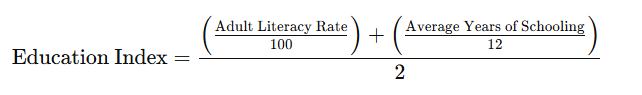




| Value Range    | Interpretation      |
| -------------- | ------------------- |
| **0 – 0.5**    | Low education level |
| **0.5 – 0.7**  | Moderate            |
| **0.7 – 0.85** | Good                |
| **0.85 – 1.0** | Very high           |


In [39]:
df_education_index['education_index']=((df_education_index['adult_literacy_rate']/100) + (df_education_index['average_years_of_schooling']/12)/2)
df_education_index

,country,year,adult_literacy_rate,youth_literacy_rate_male,youth_literacy_rate_female,region,illerate_percent,literacy_gender_gap,gdp,average_years_of_schooling,population,gdp_per_schooling_year,education_index
0,Afghanistan,2011,31.00000,62.00000,32.00000,Asia,69.00000,30.00000,2757.0525,4.106,29347708.0,671.469191,0.481083
1,Afghanistan,2015,33.75384,57.73505,25.48416,Asia,66.24616,32.25089,2967.6921,4.810,33831767.0,616.983805,0.537955
2,Afghanistan,2021,37.00000,71.00000,42.00000,Asia,63.00000,29.00000,2144.1665,5.690,40000410.0,376.830668,0.607083
3,Albania,2001,99.00000,99.00000,99.00000,Europe,1.00000,0.00000,7232.9907,9.992,3147943.0,723.878173,1.406333
4,Albania,2008,96.00000,99.00000,99.00000,Europe,4.00000,0.00000,11056.3520,10.360,2992933.0,1067.215444,1.391667
...,...,...,...,...,...,...,...,...,...,...,...,...,...
647,Zambia,2002,69.00000,78.00000,66.00000,Africa,31.00000,12.00000,2299.3330,6.446,10647955.0,356.706950,0.958583
648,Zambia,2010,83.00000,91.00000,87.00000,Africa,17.00000,4.00000,3266.5076,7.400,13965592.0,441.419946,1.138333
649,Zambia,2018,71.13230,82.44786,72.90992,Africa,28.86770,9.53794,3646.9597,8.182,17973574.0,445.729614,1.052240
650,Zimbabwe,1992,84.00000,97.00000,94.00000,Africa,16.00000,3.00000,5532.0376,6.322,10702697.0,875.045492,1.103417


**Youth Literacy Average**

In [40]:
df_education_index['avg_youth_literacy']=((df_education_index['youth_literacy_rate_male']+df_education_index['youth_literacy_rate_female'])/2)
df_education_index

,country,year,adult_literacy_rate,youth_literacy_rate_male,youth_literacy_rate_female,region,illerate_percent,literacy_gender_gap,gdp,average_years_of_schooling,population,gdp_per_schooling_year,education_index,avg_youth_literacy
0,Afghanistan,2011,31.00000,62.00000,32.00000,Asia,69.00000,30.00000,2757.0525,4.106,29347708.0,671.469191,0.481083,47.000000
1,Afghanistan,2015,33.75384,57.73505,25.48416,Asia,66.24616,32.25089,2967.6921,4.810,33831767.0,616.983805,0.537955,41.609605
2,Afghanistan,2021,37.00000,71.00000,42.00000,Asia,63.00000,29.00000,2144.1665,5.690,40000410.0,376.830668,0.607083,56.500000
3,Albania,2001,99.00000,99.00000,99.00000,Europe,1.00000,0.00000,7232.9907,9.992,3147943.0,723.878173,1.406333,99.000000
4,Albania,2008,96.00000,99.00000,99.00000,Europe,4.00000,0.00000,11056.3520,10.360,2992933.0,1067.215444,1.391667,99.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
647,Zambia,2002,69.00000,78.00000,66.00000,Africa,31.00000,12.00000,2299.3330,6.446,10647955.0,356.706950,0.958583,72.000000
648,Zambia,2010,83.00000,91.00000,87.00000,Africa,17.00000,4.00000,3266.5076,7.400,13965592.0,441.419946,1.138333,89.000000
649,Zambia,2018,71.13230,82.44786,72.90992,Africa,28.86770,9.53794,3646.9597,8.182,17973574.0,445.729614,1.052240,77.678890
650,Zimbabwe,1992,84.00000,97.00000,94.00000,Africa,16.00000,3.00000,5532.0376,6.322,10702697.0,875.045492,1.103417,95.500000


**Literacy Growth Rate**

In [41]:
df_literacy = df_literacy.sort_values(['country', 'year'])
df_literacy['literacy_growth_rate'] = (
    df_literacy.groupby('country')['adult_literacy_rate']
    .pct_change() * 100
)
df_literacy

,country,year,adult_literacy_rate,youth_literacy_rate_male,youth_literacy_rate_female,region,illerate_percent,literacy_gender_gap,literacy_growth_rate
1,Afghanistan,2011,31.00000,62.00000,32.00000,Asia,69.00000,30.00000,NaN
2,Afghanistan,2015,33.75384,57.73505,25.48416,Asia,66.24616,32.25089,8.883355
3,Afghanistan,2021,37.00000,71.00000,42.00000,Asia,63.00000,29.00000,9.617158
5,Albania,2001,99.00000,99.00000,99.00000,Europe,1.00000,0.00000,NaN
7,Albania,2008,96.00000,99.00000,99.00000,Europe,4.00000,0.00000,-3.030303
...,...,...,...,...,...,...,...,...,...
2011,Zambia,2002,69.00000,78.00000,66.00000,Africa,31.00000,12.00000,1.470588
2012,Zambia,2010,83.00000,91.00000,87.00000,Africa,17.00000,4.00000,20.289855
2013,Zambia,2018,71.13230,82.44786,72.90992,Africa,28.86770,9.53794,-14.298434
2015,Zimbabwe,1992,84.00000,97.00000,94.00000,Africa,16.00000,3.00000,NaN


# **EDA**

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

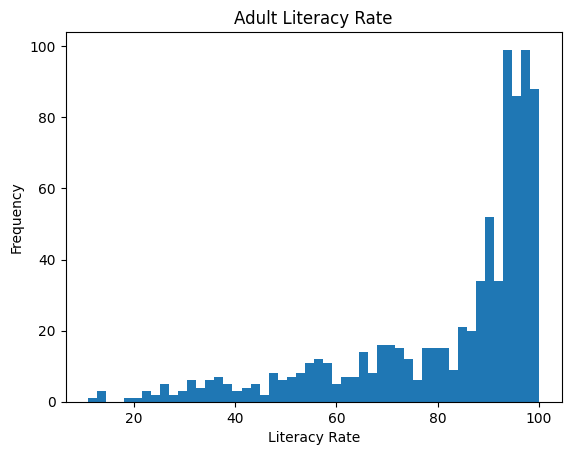

In [43]:
plt.hist(df_literacy['adult_literacy_rate'], bins=50)
plt.title("Distribution of Adult Literacy Rate")
plt.xlabel("Literacy Rate")
plt.ylabel("Frequency")
plt.show()

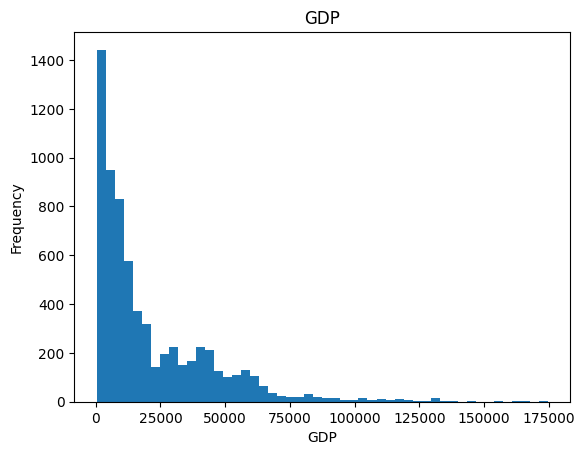

In [44]:
plt.hist(df_gdp_schooling['gdp'], bins=50)
plt.title("Distribution of GDP")
plt.xlabel("GDP")
plt.ylabel("Frequency")
plt.show()

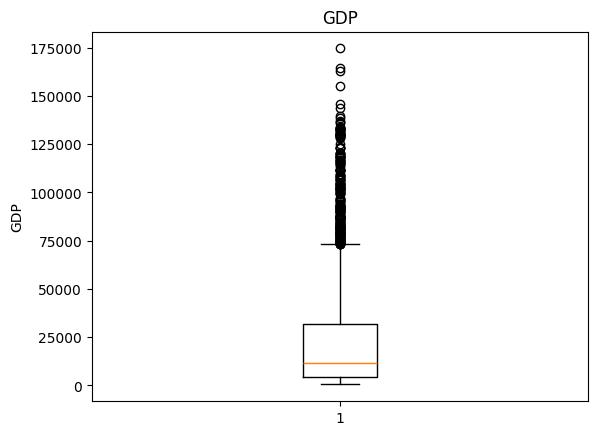

In [46]:
plt.boxplot(df_gdp_schooling['gdp'])
plt.title("GDP")
plt.ylabel("GDP")
plt.show()

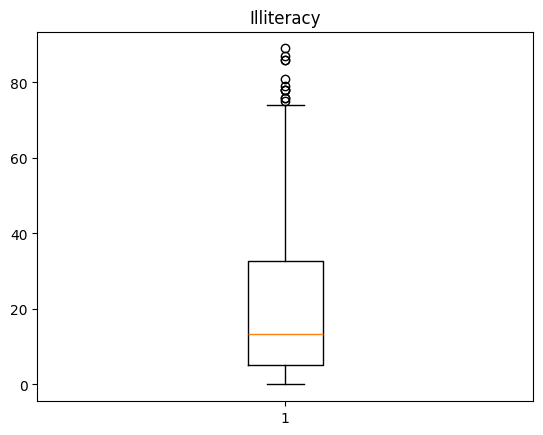

In [47]:
plt.boxplot(df_illiteracy['illiteracy_rate'])
plt.title("Illiteracy")
plt.show()

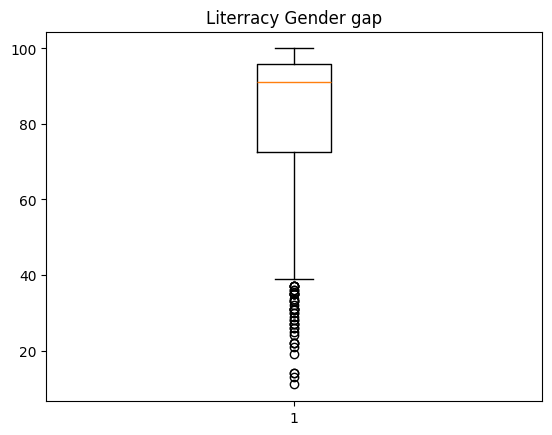

In [48]:
plt.boxplot(df_literacy['adult_literacy_rate'])
plt.title("Literracy Gender gap")
plt.show()

In [49]:
adult_literacy_rate=df_literacy['adult_literacy_rate'].groupby(df_literacy['country']).mean()
adult_literacy_rate=adult_literacy_rate.sort_values(ascending=False)

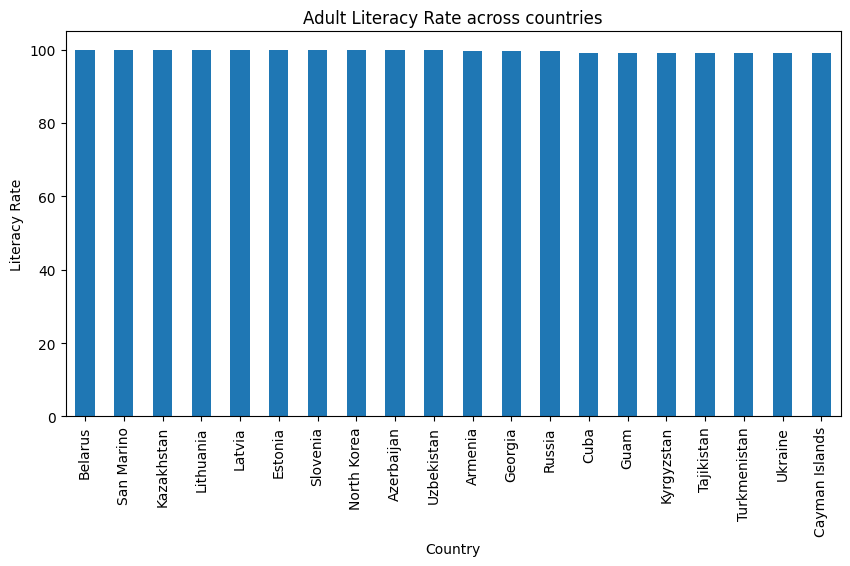

In [50]:
adult_literacy_rate.head(20).plot(kind='bar',figsize=(10,5))
plt.title("Adult Literacy Rate across countries")
plt.xlabel("Country")
plt.ylabel("Literacy Rate")
plt.show()

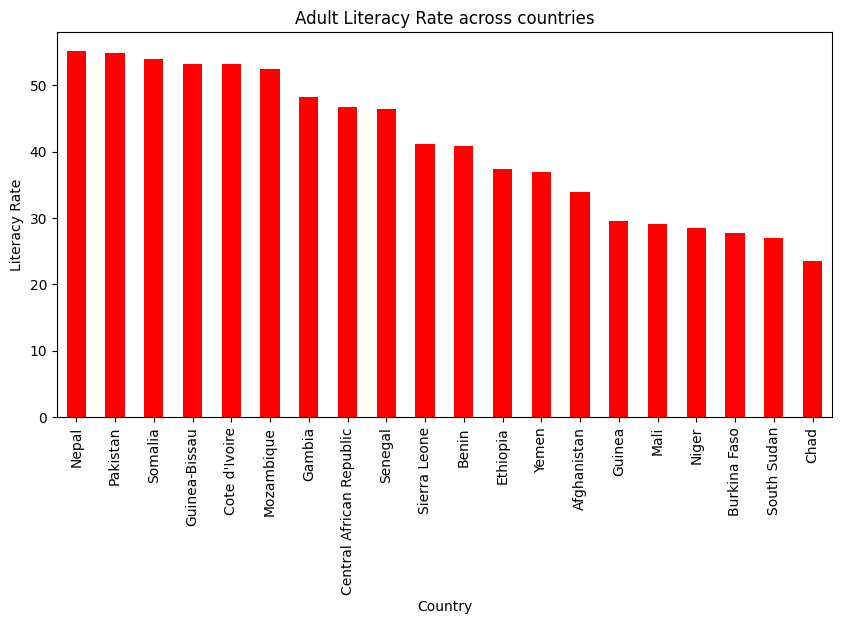

In [51]:
adult_literacy_rate.tail(20).plot(kind='bar',figsize=(10,5),color="red")
plt.title("Adult Literacy Rate across countries")
plt.xlabel("Country")
plt.ylabel("Literacy Rate")
plt.show()

In [52]:
adult_literacy_rate_region=df_literacy['adult_literacy_rate'].groupby(df_literacy['region']).mean()
adult_literacy_rate_region=adult_literacy_rate_region.sort_values(ascending=False)

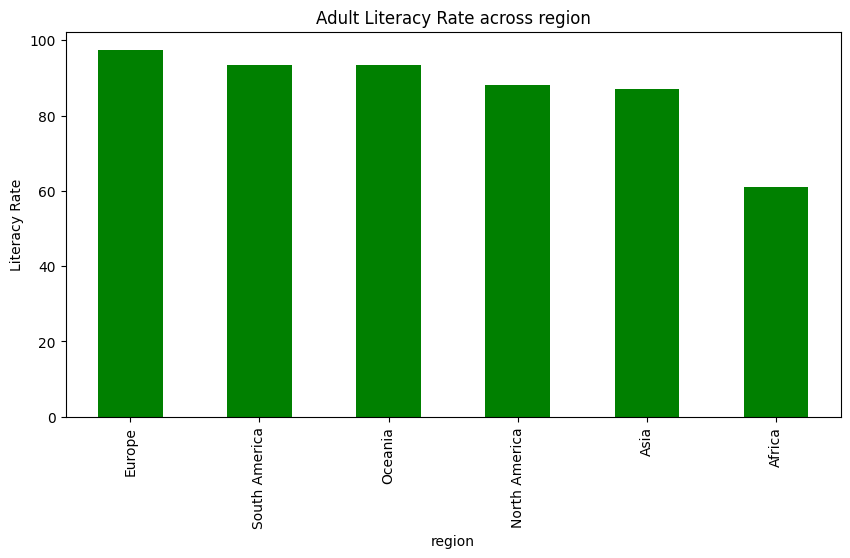

In [53]:
adult_literacy_rate_region.plot(kind='bar',figsize=(10,5),color="green")
plt.title("Adult Literacy Rate across region")
plt.xlabel("region")
plt.ylabel("Literacy Rate")
plt.show()

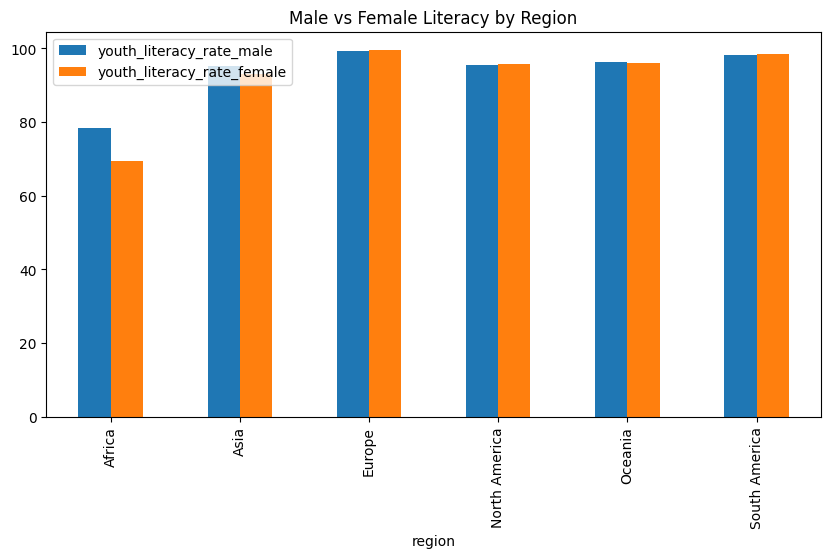

In [54]:
gender_gap = df_literacy.groupby('region')[['youth_literacy_rate_male',
                                   'youth_literacy_rate_female']].mean()

gender_gap.plot(kind='bar', figsize=(10, 5))
plt.title("Male vs Female Literacy by Region")
plt.show()

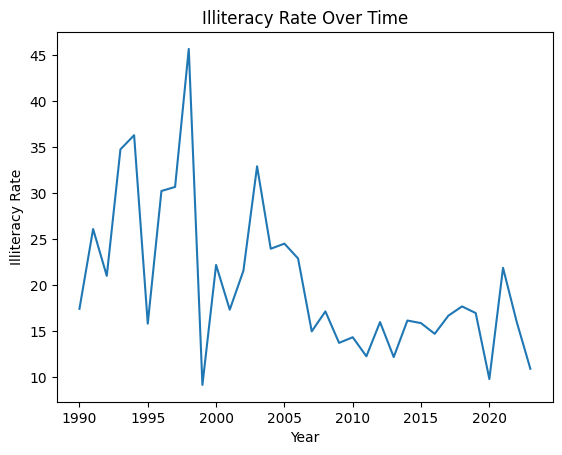

In [86]:
illiteracy=df_literacy.groupby(['year'])['illerate_percent'].mean()
illiteracy.plot(kind='line')
plt.title("Illiteracy Rate Over Time")
plt.xlabel("Year")
plt.ylabel("Illiteracy Rate")
plt.show()

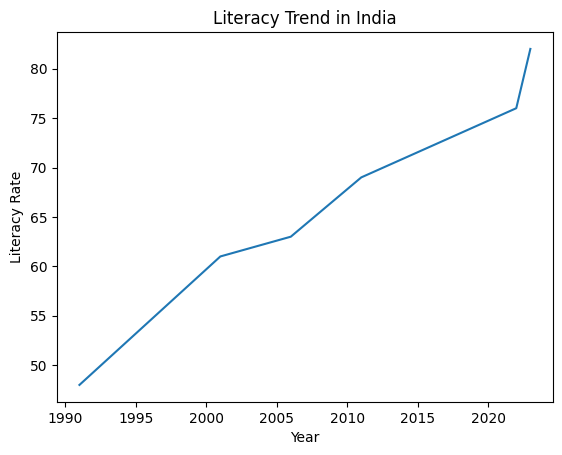

In [56]:
country_data = df_literacy[df_literacy['country'] == 'India']

plt.plot(country_data['year'], country_data['adult_literacy_rate'])
plt.title("Literacy Trend in India")
plt.xlabel("Year")
plt.ylabel("Literacy Rate")
plt.show()

/tmp/ipykernel_8690/1579257874.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


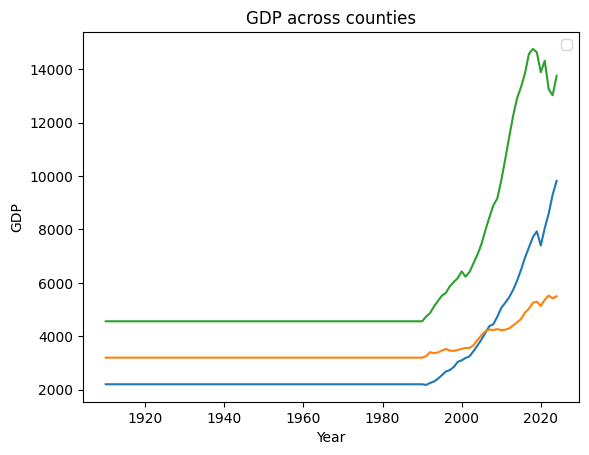

In [57]:
gdp_data1 = df_gdp_schooling[(df_gdp_schooling['country'] == 'India')]
gdp_data2=df_gdp_schooling[(df_gdp_schooling['country'] == 'Pakistan')]
gdp_data3=df_gdp_schooling[(df_gdp_schooling['country'] == 'Sri Lanka')]

plt.plot(gdp_data1['year'], gdp_data1['gdp'],)
plt.plot(gdp_data2['year'], gdp_data2['gdp'],)
plt.plot(gdp_data3['year'], gdp_data3['gdp'],)
plt.title("GDP across counties")
plt.xlabel("Year")
plt.ylabel("GDP")
plt.legend()
plt.show()

In [58]:
df_gdp_schooling['country'].unique()

array(['Afghanistan', 'Albania', 'Algeria', 'Argentina', 'Armenia',
       'Australia', 'Austria', 'Bahrain', 'Bangladesh', 'Barbados',
       'Belgium', 'Belize', 'Benin', 'Bolivia', 'Botswana', 'Brazil',
       'Brunei', 'Bulgaria', 'Burundi', 'Cambodia', 'Cameroon', 'Canada',
       'Central African Republic', 'Chile', 'China', 'Colombia', 'Congo',
       'Costa Rica', "Cote d'Ivoire", 'Croatia', 'Cyprus', 'Czechia',
       'Democratic Republic of Congo', 'Denmark', 'Dominican Republic',
       'Ecuador', 'Egypt', 'El Salvador', 'Estonia', 'Eswatini', 'Fiji',
       'Finland', 'France', 'Gabon', 'Gambia', 'Germany', 'Ghana',
       'Greece', 'Guatemala', 'Guyana', 'Haiti', 'Honduras', 'Hong Kong',
       'Hungary', 'Iceland', 'India', 'Indonesia', 'Iran', 'Iraq',
       'Ireland', 'Israel', 'Italy', 'Jamaica', 'Japan', 'Jordan',
       'Kazakhstan', 'Kenya', 'Kuwait', 'Kyrgyzstan', 'Laos', 'Latvia',
       'Lesotho', 'Liberia', 'Libya', 'Lithuania', 'Luxembourg', 'Macao',
       'Ma

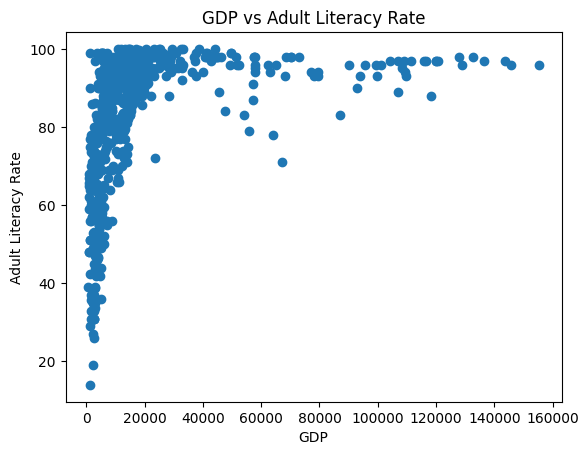

In [59]:
plt.scatter(df_education_index['gdp'],df_education_index['adult_literacy_rate'])
plt.title("GDP vs Adult Literacy Rate")
plt.xlabel("GDP")
plt.ylabel("Adult Literacy Rate")
plt.show()

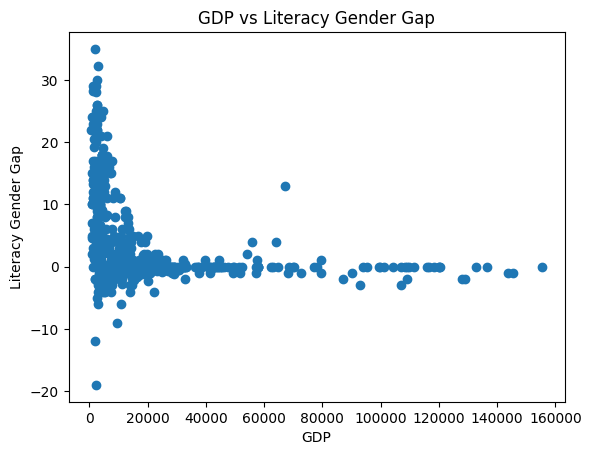

In [60]:
plt.scatter(df_education_index['gdp'],df_education_index['literacy_gender_gap'])
plt.title("GDP vs Literacy Gender Gap")
plt.xlabel("GDP")
plt.ylabel("Literacy Gender Gap")
plt.show()

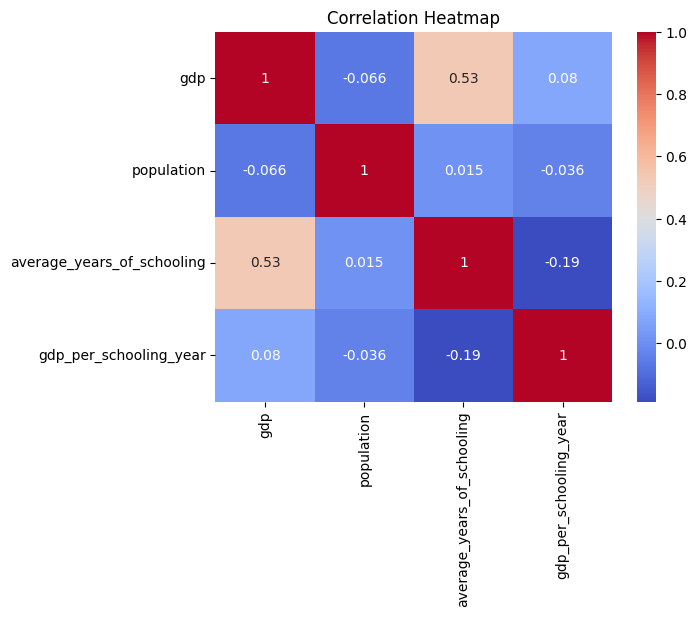

In [61]:
corre=df_gdp_schooling[['gdp','population','average_years_of_schooling', 'gdp_per_schooling_year']].corr()
sns.heatmap(corre, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# **SQL**

In [62]:
df_literacy

,country,year,adult_literacy_rate,youth_literacy_rate_male,youth_literacy_rate_female,region,illerate_percent,literacy_gender_gap,literacy_growth_rate
1,Afghanistan,2011,31.00000,62.00000,32.00000,Asia,69.00000,30.00000,NaN
2,Afghanistan,2015,33.75384,57.73505,25.48416,Asia,66.24616,32.25089,8.883355
3,Afghanistan,2021,37.00000,71.00000,42.00000,Asia,63.00000,29.00000,9.617158
5,Albania,2001,99.00000,99.00000,99.00000,Europe,1.00000,0.00000,NaN
7,Albania,2008,96.00000,99.00000,99.00000,Europe,4.00000,0.00000,-3.030303
...,...,...,...,...,...,...,...,...,...
2011,Zambia,2002,69.00000,78.00000,66.00000,Africa,31.00000,12.00000,1.470588
2012,Zambia,2010,83.00000,91.00000,87.00000,Africa,17.00000,4.00000,20.289855
2013,Zambia,2018,71.13230,82.44786,72.90992,Africa,28.86770,9.53794,-14.298434
2015,Zimbabwe,1992,84.00000,97.00000,94.00000,Africa,16.00000,3.00000,NaN


In [63]:
import sqlite3
conn=sqlite3.connect('gb_literacy.db')
cursor=conn.cursor()

In [64]:
conn.execute(''' create table literacy_rates(country varchar(20), year int, adult_literacy decimal(20,6), youth_male_lit decimal(20,6), youth_female_lit decimal(20,6),region varchar(10),illerate_per decimal(20,6),lit_gender_gap decimal(20,6),lit_growth_rate decimal(20,6),primary key(country,year))''')

In [65]:
conn.execute(''' create table illiteracy_pop (country varchar(20), year int, illerate_rate decimal(20,6),literacy_rate decimal(20,6), primary key(country,year))''')

In [66]:
conn.execute('''create table gdp_schooling(country varchar(20), year int, gdp decimal(20,6), avg_yrs_schooling decimal(18,2),population decimal(20,6), gdp_per_schooling decimal(18,6),primary key(country,year))''')

In [67]:
conn.commit()

In [68]:
conn =sqlite3.connect("gb_literacy.db")
df_literacy.to_sql("literacy_rates",conn,if_exists="replace",index=False)
df_illiteracy.to_sql("illiteracy_population",conn,if_exists="replace",index=False)
df_gdp_schooling.to_sql("gdp_schooling",conn,if_exists="replace",index=False)

6740

In [69]:
df_literacy.to_csv("literacy_rates.csv", index=False)
df_illiteracy.to_csv("illiteracy_population.csv", index=False)
df_gdp_schooling.to_csv("gdp_schooling.csv", index=False)


1. Get top 5 countries with highest adult literacy in 2020.

In [70]:
l1=pd.read_sql('''select country,adult_literacy_rate from literacy_rates where year=2020 order by adult_literacy_rate desc limit 5''',conn)
l1

,country,adult_literacy_rate
0,Armenia,100.0
1,Mongolia,99.0
2,Spain,99.0
3,Palestine,98.0
4,Philippines,98.0


2. Find countries where female youth literacy < 80%.

In [71]:
l2=pd.read_sql('''select country,youth_literacy_rate_female from literacy_rates where youth_literacy_rate_female<80 group by country order by youth_literacy_rate_female ''',conn)
l2

,country,youth_literacy_rate_female
0,Chad,9.0
1,Guinea,13.0
2,Burkina Faso,14.0
3,Niger,14.0
4,Mali,17.0
5,Benin,27.0
6,Ethiopia,28.0
7,South Sudan,30.0
8,Afghanistan,32.0
9,Nepal,33.0


3. Average adult literacy per continent (owid region).

In [72]:
l3=pd.read_sql('''select region,avg(adult_literacy_rate) as Avg_literacy_rate from literacy_rates group by region order by Avg_literacy_rate''',conn)
l3

,region,Avg_literacy_rate
0,Africa,60.913878
1,Asia,87.146511
2,North America,87.986129
3,Oceania,93.445866
4,South America,93.466994
5,Europe,97.396630


ILLITERACY_POPULATION

In [73]:
df_illiteracy

,country,year,illiteracy_rate,literacy_rate
2,Afghanistan,2011,69.000000,31.00000
3,Afghanistan,2015,66.246155,33.75384
4,Afghanistan,2021,63.000000,37.00000
6,Albania,2001,1.000000,99.00000
7,Albania,2008,4.000000,96.00000
...,...,...,...,...
2051,Zambia,2002,31.000000,69.00000
2052,Zambia,2010,17.000000,83.00000
2053,Zambia,2018,28.867699,71.13230
2057,Zimbabwe,1992,16.000000,84.00000


 4. Countries with illiteracy % > 20% in 2000.

In [74]:
i1=pd.read_sql('''select country,illiteracy_rate from illiteracy_population where year=2000 and illiteracy_rate>20 order by illiteracy_rate''',conn)
i1

,country,illiteracy_rate
0,Saudi Arabia,21.000000
1,Middle-income countries,21.022774
2,Iraq,26.000000
3,Northern Africa and Western Asia (SDG),27.835136
4,Madagascar,29.000000
5,Laos,30.000000
6,Middle East and North Africa (WB),30.598412
7,Cameroon,32.000000
8,Comoros,32.000000
9,Oceania (excluding Australia and New Zealand) ...,34.648680


 5. Trend of illiteracy % for India (2000–2020).


In [75]:
i2=pd.read_sql('''select country,year,illiteracy_rate from illiteracy_population where country="India" ''',conn)
i2

,country,year,illiteracy_rate
0,India,1991,52.0
1,India,2001,39.0
2,India,2006,37.0
3,India,2011,31.0
4,India,2022,24.0
5,India,2023,18.0


     6. Top 10 countries with largest illiterate population in the last year.

In [76]:
i3=pd.read_sql('''select country,illiteracy_rate,year from illiteracy_population where year=(select max(year) from illiteracy_population) order by illiteracy_rate desc limit 10 ''',conn)
i3

,country,illiteracy_rate,year
0,Senegal,49.644180,2023
1,Low-income countries,36.961470,2023
2,Sub-Saharan Africa (WB),31.803757,2023
3,Sub-Saharan Africa (SDG),31.497803,2023
4,South Asia (WB),24.991150,2023
5,Central and Southern Asia (SDG),23.485687,2023
6,Lower-middle-income countries,22.368180,2023
7,Middle East and North Africa (WB),19.050858,2023
8,Northern Africa and Western Asia (SDG),18.474640,2023
9,India,18.000000,2023


In [77]:
df_gdp_schooling

,country,year,gdp,average_years_of_schooling,population,gdp_per_schooling_year
8,Afghanistan,1910,1617.8264,0.01,5504191.0,161782.640000
9,Afghanistan,1915,1617.8264,0.02,7654918.0,80891.320000
10,Afghanistan,1920,1617.8264,0.03,10188845.0,53927.546667
11,Afghanistan,1925,1617.8264,0.04,8416077.0,40445.660000
12,Afghanistan,1930,1617.8264,0.04,6626142.0,40445.660000
...,...,...,...,...,...,...
11006,Zimbabwe,2020,4527.7197,8.32,15526887.0,544.197079
11007,Zimbabwe,2021,4827.0890,8.32,15526887.0,580.178966
11008,Zimbabwe,2022,5036.7610,8.32,15526887.0,605.379928
11009,Zimbabwe,2023,5218.0225,8.32,15526887.0,627.166166


    7. Find countries with avg_years_schooling > 7 and gdp_per_capita < 5000.

In [78]:
g1=pd.read_sql(''' select country,average_years_of_schooling,gdp from gdp_schooling where average_years_of_schooling>7 and gdp<5000 and year=2023''' ,conn)
g1

,country,average_years_of_schooling,gdp
0,Cameroon,7.37,4875.2510
1,Tajikistan,10.12,4472.3240
2,Togo,7.68,2842.2307
3,Zambia,8.37,3673.4841


8. Rank countries by GDP per schooling for the year 2020.

In [79]:
g2=pd.read_sql('''select country,gdp_per_schooling_year from gdp_schooling where year=2020 order by gdp_per_schooling_year desc''',conn)
g2

,country,gdp_per_schooling_year
0,Qatar,12096.467136
1,Luxembourg,11263.281006
2,Singapore,8873.892802
3,Brunei,8650.959052
4,Kuwait,7458.129909
...,...,...
136,Malawi,306.181109
137,Democratic Republic of Congo,280.624330
138,Liberia,258.168448
139,Central African Republic,244.950560


9. Find global average schooling years per year.


In [80]:
g3=pd.read_sql(''' select year,avg(average_years_of_schooling) as Global_average_schooling from gdp_schooling group by year''',conn)
g3

,year,Global_average_schooling
0,1910,1.363396
1,1911,1.890714
2,1914,2.080000
3,1915,1.554057
4,1917,0.265000
...,...,...
76,2020,9.340780
77,2021,9.340780
78,2022,9.340780
79,2023,9.350929


   10. List top 10 countries in 2020 with highest GDP per capita but lowest average years of schooling(less than 6).

In [81]:
j1=pd.read_sql('''select country,gdp,average_years_of_schooling from gdp_schooling where year=2020 and average_years_of_schooling < 6 order by gdp desc limit 10''',conn)
j1

,country,gdp,average_years_of_schooling
0,Cambodia,6128.7820,5.81
1,Mauritania,5963.2354,5.55
2,Papua New Guinea,4077.6313,4.84
3,Senegal,4018.0413,4.40
4,Sudan,3401.2498,4.38
5,Haiti,3239.8354,5.95
6,Mali,2796.4104,3.55
7,Afghanistan,2769.6858,5.69
8,Sierra Leone,2752.6262,4.99
9,Gambia,2702.3190,4.92


 11. Show countries where the illiterate population is high despite having more than 10 average years of schooling.


In [82]:
j2=pd.read_sql('''select i.country,i.illiteracy_rate,g.average_years_of_schooling from illiteracy_population i join gdp_schooling g on i.country = g.country and i.year = g.year where g.average_years_of_schooling > 10 and i.illiteracy_rate > 10 order by i.illiteracy_rate desc''',conn)
j2

,country,illiteracy_rate,average_years_of_schooling
0,Botswana,31.000000,10.270
1,Botswana,19.000000,10.270
2,South Africa,13.000000,10.278
3,Malta,12.000000,10.060
4,Gabon,11.141663,10.180
5,Singapore,11.000000,12.540


 12. Compare literacy rates and GDP per capita growth for a selected country over the last 20 years. (country of your choice)


In [83]:
j3=pd.read_sql('''select l.country,l.year,l.adult_literacy_rate	,l.youth_literacy_rate_male,l.youth_literacy_rate_female,g.gdp,g.average_years_of_schooling	 from literacy_rates l join gdp_schooling g on l.country=g.country and l.year=g.year where l.country="India" ''',conn)
j3

,country,year,adult_literacy_rate,youth_literacy_rate_male,youth_literacy_rate_female,gdp,average_years_of_schooling
0,India,1991,48.0,74.0,49.0,2178.6860,3.708
1,India,2001,61.0,84.0,68.0,3188.8103,5.428
2,India,2006,63.0,88.0,74.0,4129.7783,6.070
3,India,2011,69.0,90.0,82.0,5249.5493,6.734
4,India,2022,76.0,97.0,96.0,8594.3920,7.800
5,India,2023,82.0,98.0,96.0,9301.7560,7.800


In [84]:
j3=pd.read_sql('''select l.country,l.year,l.adult_literacy_rate	,l.youth_literacy_rate_male,l.youth_literacy_rate_female,g.gdp,g.average_years_of_schooling	 from literacy_rates l join gdp_schooling g on l.country=g.country and l.year=g.year where l.country="Singapore" ''',conn)
j3

,country,year,adult_literacy_rate,youth_literacy_rate_male,youth_literacy_rate_female,gdp,average_years_of_schooling
0,Singapore,1990,89.0,99.0,99.0,45567.790,12.540
1,Singapore,2000,93.0,99.0,100.0,68314.550,12.540
2,Singapore,2010,96.0,100.0,100.0,95456.190,12.540
3,Singapore,2011,96.0,100.0,100.0,99296.760,12.540
4,Singapore,2012,96.0,100.0,100.0,101187.830,12.540
5,Singapore,2013,97.0,100.0,100.0,104359.030,12.540
6,Singapore,2014,97.0,100.0,100.0,107066.860,12.540
7,Singapore,2015,97.0,100.0,100.0,108953.730,12.540
8,Singapore,2016,97.0,100.0,100.0,111579.740,12.644
9,Singapore,2017,97.0,100.0,100.0,116471.820,12.748


  13. Show the difference between youth literacy male and female rates for countries with GDP per capita above $30,000 in 2020.


In [85]:
j4=pd.read_sql('''select l.country,l.youth_literacy_rate_male,	l.youth_literacy_rate_female,g.gdp from literacy_rates l join gdp_schooling g on l.country=g.country and l.year=g.year where g.gdp>30000 and g.year=2020''',conn	)
j4

,country,youth_literacy_rate_male,youth_literacy_rate_female,gdp
0,Kuwait,99.0,100.0,49372.820
1,Saudi Arabia,100.0,99.0,57420.734
2,Singapore,100.0,100.0,115893.040
3,Spain,99.0,100.0,41553.450
